<a href="https://colab.research.google.com/github/deancallahan25/Redwood-Analytics-Portfolio/blob/main/Dean_Callahan_Project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 3 Dean Callahan Tree Biomass Prediction (Linear Regression vs. kNN)



This notebook demonstrates prediction intervals for linear regression and kNN using tree data from LegacyTreeData v2 (subset of NSVB_tree.csv dataset). This subset contains three field measurements which will be used to predict tree biomass: diameter, height, and species.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_squared_log_error
from sklearn.preprocessing import StandardScaler
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Import Data and Preview



In [2]:
from google.colab import drive
drive.mount('/content/drive')

df=pd.read_csv("/content/drive/MyDrive/DATA 311 Redwood Analytics/Project 3/biomass_model_dataset.csv")
print(df.head())
print(f"\nSummary Statistics")
print(df.describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   SPCD  DO_BH  HT_TOT  TT_DW_CRM
0    12    7.5    45.2     178.86
1    12    9.3    62.7     323.46
2    12    9.7    56.7     342.47
3    12   11.4    66.1     499.35
4    12    6.4    51.8     113.92

Summary Statistics
                SPCD          DO_BH         HT_TOT     TT_DW_CRM
count  137079.000000  137079.000000  137079.000000  1.370790e+05
mean      341.054465      11.104809      62.081565  1.530719e+03
std       341.609599       8.046896      25.834963  1.698299e+04
min        10.000000       1.000000       1.400000  1.020000e+00
25%       121.000000       6.500000      45.000000  1.689850e+02
50%       132.000000       9.900000      61.100000  5.276000e+02
75%       611.000000      14.300000      76.700000  1.352070e+03
max      8768.000000     334.900000     379.300000  1.385886e+06


## Data Dictionary

- SPCD (Species Code): A numeric code which unqiuely identifies each tree species as specifed by the FIA (Forest Inventory and Analysis) species coding system. Each FIA species code corresponds uniquely to a scientific and common name. (Official definition: FIA species code.)
- DO_BH (Diameter at Breast Height [Outside Bark]): Diameter of the tree stem measured at breast height (4.5 feet or 1.37 meters above ground) including bark. This is the standard foresty measurement "DBH (outside bark)" and is the primary size variable used in nearly all allometric biomass models.

- HT_TOT (Total Tree Height): The total height of the tree measured from ground level to the top of the crown. Used as a second size metric in volume and biomass modeling.
- TT_DW_CRM (Total Tree Dry Biomass): The total above-ground dry weight of the tree (includes stem wood, stem bark, branches, folliage). This value comes from destructive sampling: the tree was felled, seperated into componenets, oven-dried, and weighed. This variable serves as the response variable ("target") from biomass prediction.
- COMMON_NAME: The corresponding string common name for the tree species for a FIA SPCD code.

## 2. Exploratory Data Summaries and Visualizations

In [3]:
 df_visuals=pd.read_csv("/content/drive/MyDrive/DATA 311 Redwood Analytics/Project 3/biomass_model_dataset.csv")
 full_species_codes=pd.read_csv("/content/drive/MyDrive/DATA 311 Redwood Analytics/Project 3/FIATreeSpeciesCode.csv")
 species_codes=full_species_codes[["SPCD","COMMON_NAME"]]
 df_visuals=df.merge(species_codes,on='SPCD', how='left')
 df_visuals.head()


,SPCD,DO_BH,HT_TOT,TT_DW_CRM,COMMON_NAME
0,12,7.5,45.2,178.86,balsam fir
1,12,9.3,62.7,323.46,balsam fir
2,12,9.7,56.7,342.47,balsam fir
3,12,11.4,66.1,499.35,balsam fir
4,12,6.4,51.8,113.92,balsam fir


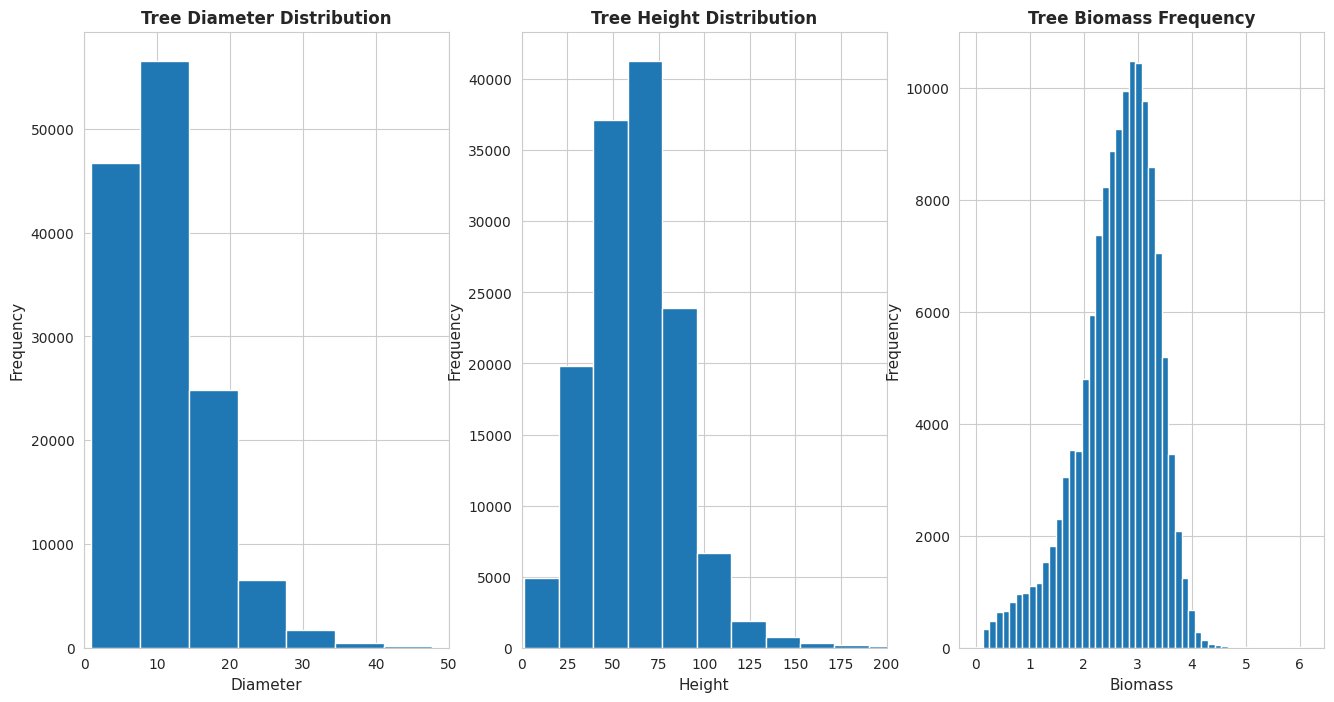

In [4]:


 #Univariate Visulizations & Summaries
 fig, axes = plt.subplots(1, 3, figsize=(16, 8))
 axes[0].hist(df['DO_BH'],bins=50)
 axes[0].set_xlim(0,50)
 axes[0].set_xlabel('Diameter', fontsize=11)
 axes[0].set_ylabel('Frequency', fontsize=11)
 axes[0].set_title('Tree Diameter Distribution', fontsize=12, fontweight='bold')

 axes[1].hist(df['HT_TOT'],bins=20)
 axes[1].set_xlim(0,200)

 axes[1].set_xlabel('Height', fontsize=11)
 axes[1].set_ylabel('Frequency', fontsize=11)
 axes[1].set_title('Tree Height Distribution', fontsize=12, fontweight='bold')

 log_biomass = np.log10(df['TT_DW_CRM'])
 axes[2].hist(log_biomass,bins=50)
 axes[2].set_xlabel('Biomass', fontsize=11)
 axes[2].set_ylabel('Frequency', fontsize=11)
 axes[2].set_title('Tree Biomass Frequency', fontsize=12, fontweight='bold')


 plt.show()


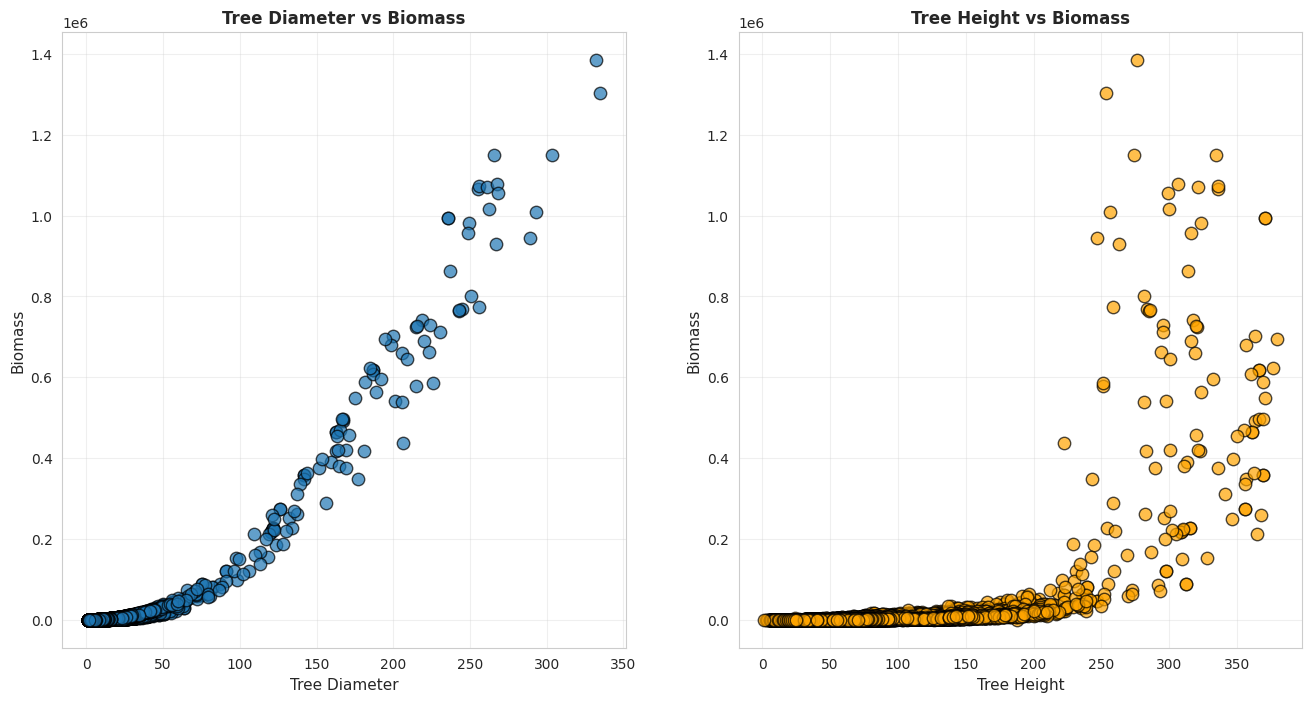

In [5]:
#Bivariate Visualizations
# Figure 2: Individual relationships
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].scatter(df['DO_BH'], df['TT_DW_CRM'], alpha=0.7, s=80, edgecolors='black')
axes[0].set_xlabel('Tree Diameter', fontsize=11)
axes[0].set_ylabel('Biomass', fontsize=11)
axes[0].set_title('Tree Diameter vs Biomass', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df['HT_TOT'], df['TT_DW_CRM'], alpha=0.7, s=80, edgecolors='black', color='orange')
axes[1].set_xlabel('Tree Height', fontsize=11)
axes[1].set_ylabel('Biomass', fontsize=11)
axes[1].set_title('Tree Height vs Biomass', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)





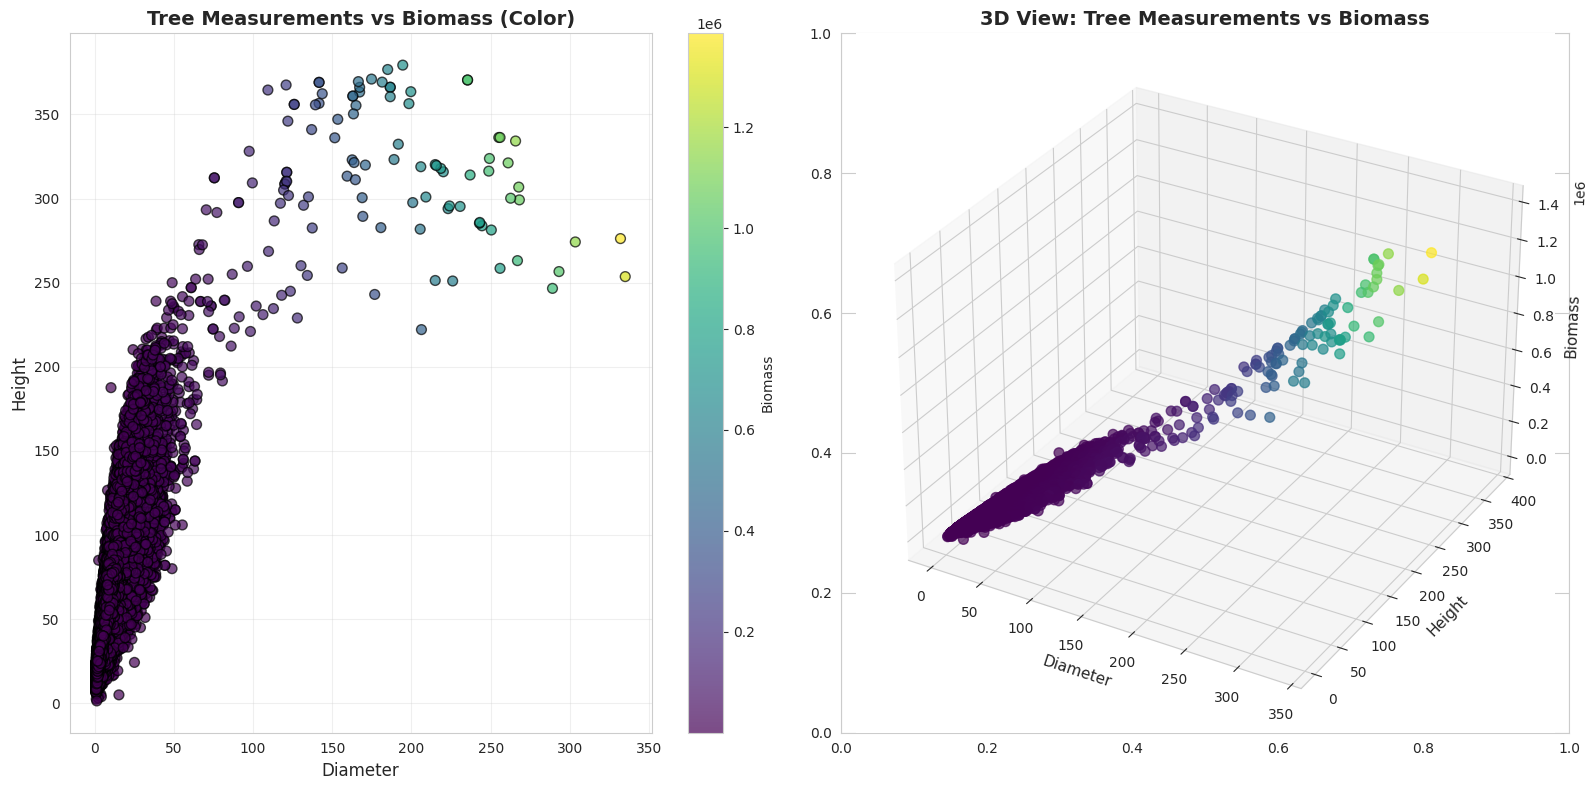

In [6]:
 #combined vars vs biomass 3d view
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Scatter plot colored by tree biomass
scatter = axes[0].scatter(df['DO_BH'], df['HT_TOT'], c=df['TT_DW_CRM'],
                         cmap='viridis', s=50, alpha=0.7, edgecolors='black')
axes[0].set_xlabel('Diameter', fontsize=12)
axes[0].set_ylabel('Height', fontsize=12)
axes[0].set_title('Tree Measurements vs Biomass (Color)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Biomass')
axes[0].grid(True, alpha=0.3)

# Right: 3D relationship (DO_BH, HT_TOT, TT_DW_CRM)
ax = fig.add_subplot(122, projection='3d')
scatter3d = ax.scatter(df['DO_BH'], df['HT_TOT'], df['TT_DW_CRM'],
                      c=df['TT_DW_CRM'], cmap='viridis', s=50, alpha=0.7)
ax.set_xlabel('Diameter', fontsize=11)
ax.set_ylabel('Height', fontsize=11)
ax.set_zlabel('Biomass', fontsize=11)
ax.set_title('3D View: Tree Measurements vs Biomass', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

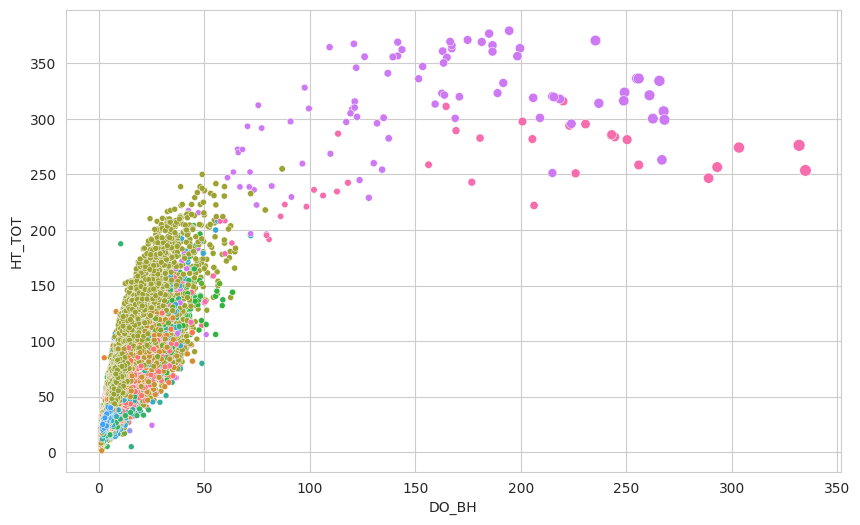

In [17]:
#Visualization Containing all 4 Variables
sns.scatterplot(data=df_visuals, x='DO_BH',y='HT_TOT',hue='COMMON_NAME',size='TT_DW_CRM',legend=False)
plt.show()

## 4. Fit KNN model

In [ ]:
training_df=pd.read_csv("/content/drive/MyDrive/DATA 311 Redwood Analytics/Project 3/training_data.csv")
testing_df=pd.read_csv("/content/drive/MyDrive/DATA 311 Redwood Analytics/Project 3/testing_data.csv")

RMSLE=[]
for name in training_df["COMMON_NAME"].unique():
  train=training_df[training_df['COMMON_NAME']==name]
  test=testing_df[testing_df['COMMON_NAME']==name]
  X_train=train[['DO_BH','HT_TOT']]
  y_train = train['TT_DW_CRM']
  X_test = test[['DO_BH', 'HT_TOT']]
  y_test = test['TT_DW_CRM']
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  k = 3
  knn = KNeighborsRegressor(n_neighbors=k)
  knn.fit(X_train_scaled, y_train)
  y_pred = knn.predict(X_test_scaled)
  rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))
  RMSLE.append((name, rmsle))
  #ensemble or change distance or weighted distance



In [ ]:
rmsle_df = pd.DataFrame(RMSLE, columns=['COMMON_NAME', 'RMSLE'])
print(rmsle_df.to_string(index=False))

                COMMON_NAME    RMSLE
                balsam fir  0.123746
         eastern white pine 0.131025
            eastern hemlock 0.196506
                  red maple 0.103740
                sugar maple 0.223838
               yellow birch 0.196006
                  white ash 0.292819
                  black ash 0.123011
             bigtooth aspen 0.106754
              quaking aspen 0.078667
           northern red oak 0.129594
          American basswood 0.188086
                  jack pine 0.075951
                   red pine 0.202294
                paper birch 0.252399
              balsam poplar 0.155614
             shortleaf pine 0.135564
             pignut hickory 0.280976
               black cherry 0.216810
                scarlet oak 0.150088
                   post oak 0.133523
                  black oak 0.128815
                  white oak 0.126183
               white spruce 0.143270
               black spruce 0.119676
       northern white-cedar 0.153965
 

<BarContainer object of 100 artists>

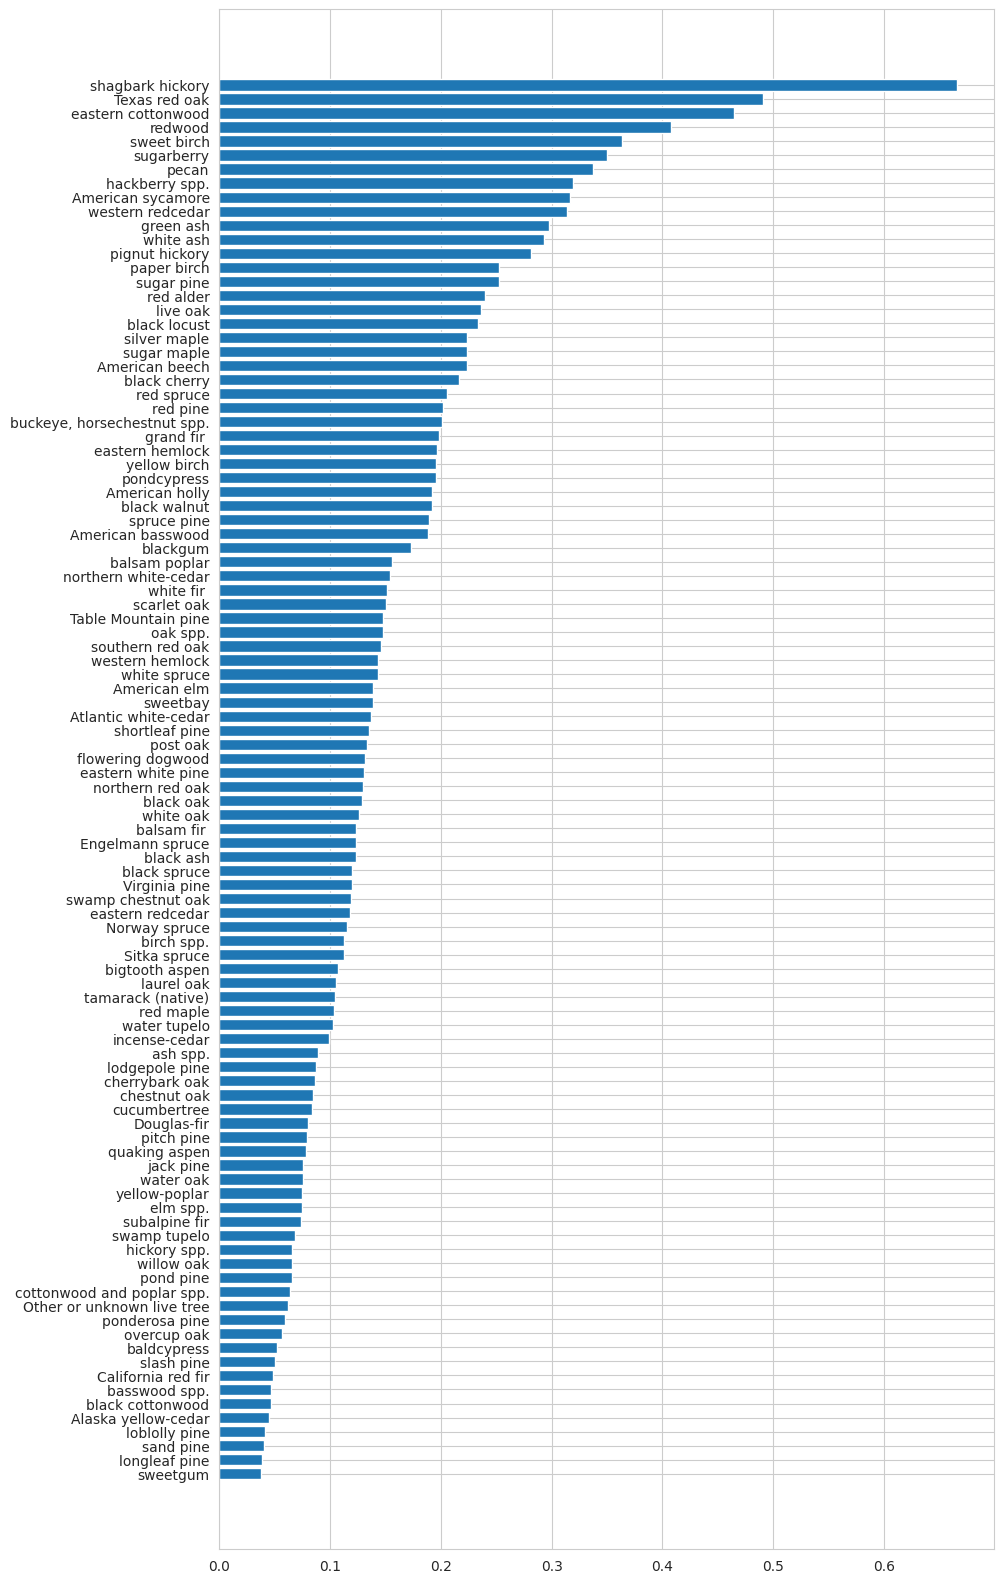

In [ ]:
rmsle_df=rmsle_df.sort_values('RMSLE',ascending=True)
rmsle_df
plt.figure(figsize=(10, 20))
plt.barh(rmsle_df['COMMON_NAME'],rmsle_df['RMSLE'])


<BarContainer object of 41 artists>

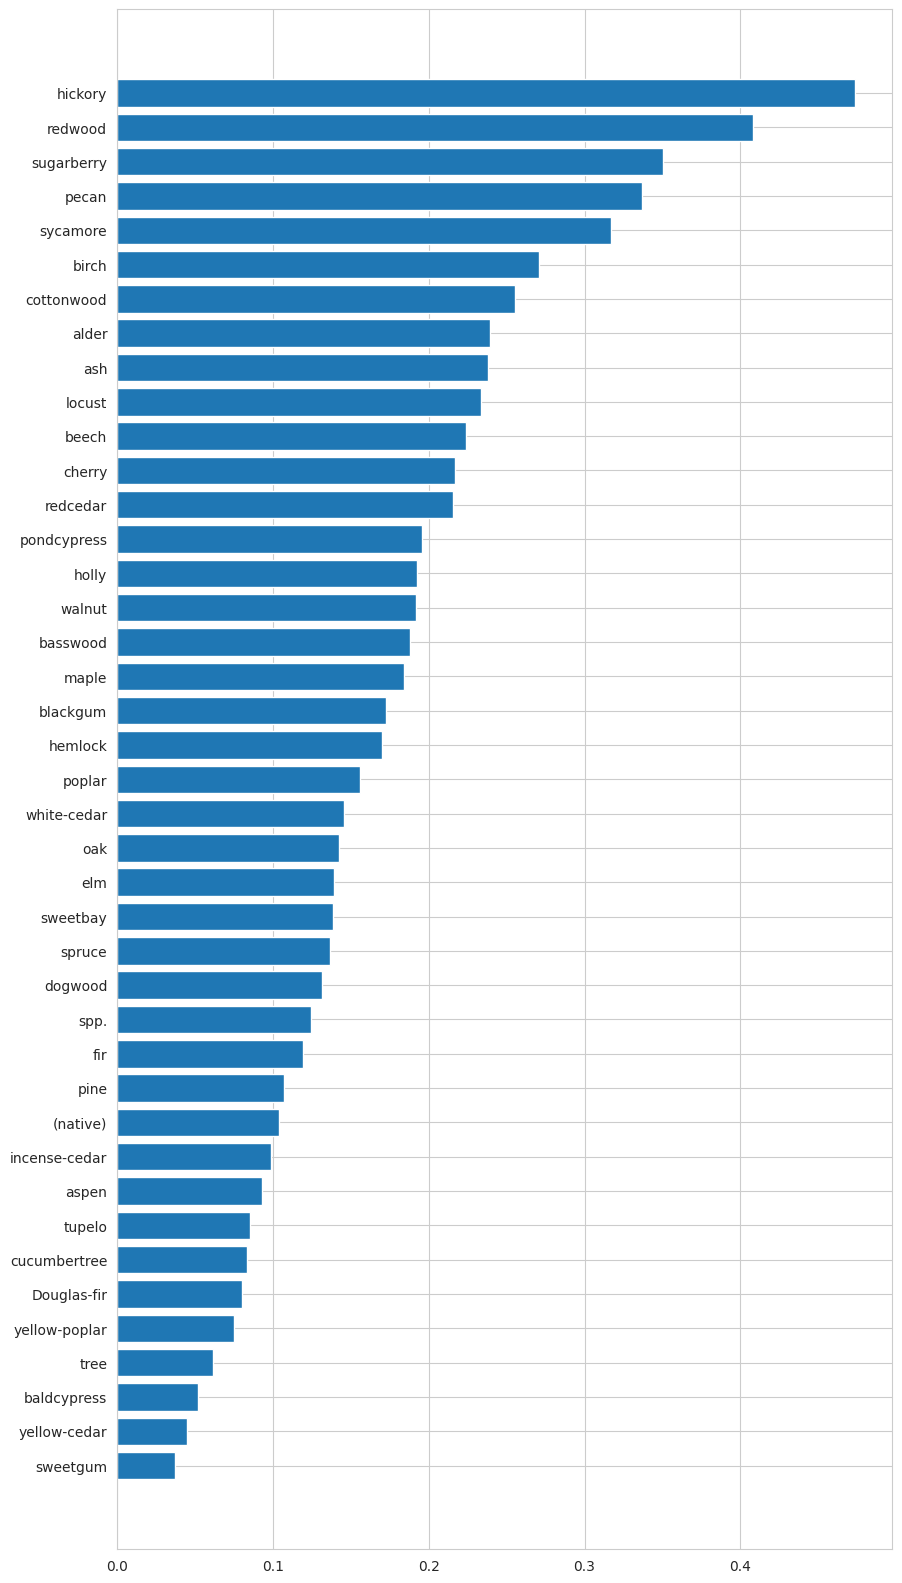

In [ ]:
rmsle_df["GROUP"] = rmsle_df["COMMON_NAME"].str.split().str[-1]
rmsle_df["GROUP"].unique()
grouped = rmsle_df.groupby("GROUP")["RMSLE"].mean().sort_values()
grouped
plt.figure(figsize=(10, 20))
plt.barh(grouped.index,grouped.values)


In [ ]:
rmsle_df['RMSLE'].mean()

np.float64(0.15808192537990742)

## Implementing KNN with selection dataset
